In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from datetime import datetime
from torch.utils.data import DataLoader

from pathlib import Path
import random
import numpy as np
import pandas as pd
import os
import json
import time
import copy
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # Auto-detect Jupyter / Terminal

from torchvision.models import resnet50, ResNet50_Weights
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Memastikan CUDA (GPU) tersedia
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU terdeteksi: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU tidak terdeteksi, menggunakan CPU.")

GPU terdeteksi: NVIDIA GeForce RTX 4060 Laptop GPU


## Konfigurasi

In [3]:
# ==============================================================================
# 1. PENGATURAN SEED (REPRODUCIBILITY)
# Tujuannya agar jika eksperimen diulang, hasilnya akan tetap sama (konsisten)
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Mengatur agar backend CuDNN berjalan deterministik
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [4]:
# ==============================================================================
# 1. KONFIGURASI PATH (FOLDER DIRECTORY)
# ==============================================================================
# Sesuaikan 'dataset/' dengan nama folder tempat Anda menyimpan data
CURRENT_DIR     = Path.cwd()

if CURRENT_DIR.name == "cnn_svm":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

OUTPUT_DIR       = CURRENT_DIR  / "dataset" 
OUTPUT_MODEL     = CURRENT_DIR  / "models" 
TRAIN_MODEL_DIR  = OUTPUT_MODEL / "train"
TEST_MODEL_DIR   = OUTPUT_MODEL / "test"

LOG_DIR = CURRENT_DIR  / "logs" 
LOG_TRAIN = LOG_DIR / "train"
LOG_TEST = LOG_DIR / "test"

TRAIN_DIR       = OUTPUT_DIR / "train"
VAL_DIR         = OUTPUT_DIR / "val"
TEST_DIR        = OUTPUT_DIR / "test"
MODEL_SAVE_PATH = OUTPUT_MODEL / 'best_cloud_model_CNN.pth' # Nama file ketika model disimpan nanti

OUTPUT_MODEL.mkdir(parents=True, exist_ok=True)
TRAIN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
TEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_TRAIN.mkdir(parents=True, exist_ok=True)
LOG_TEST.mkdir(parents=True, exist_ok=True)

In [5]:
# ==============================================================================
# 1. KONFIGURASI DATASET & DATALOADER
# ==============================================================================
NUM_CLASSES     = 7
IMAGE_SIZE      = 224 # Standar untuk ResNet, MobileNet, dll (224x224)
BATCH_SIZE      = 32  # Turunkan ke 16 atau 8 jika GPU lokal mengalami "Out of Memory"
NUM_WORKERS     = 0   # Gunakan 2 atau 4 (sesuai jumlah core CPU lokal Anda)
HASIL_TRAIN     = [] 
HASIL_TEST      = []

## Transformasi, Dataset, dan DataLoader

In [6]:
# 1. Setup Transformasi Data
# Normalisasi menggunakan rata-rata dan standar deviasi dari ImageNet
data_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [7]:
# 2. Inisialisasi Dataset menggunakan variabel Pathlib
# PyTorch ImageFolder menerima objek Pathlib tanpa perlu diubah menjadi string
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=data_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=data_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=data_transforms)

# Mengekstrak nama kelas
class_names = train_dataset.classes

# 3. Setup DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Catatan: pin_memory=True digunakan untuk mempercepat transfer data dari CPU RAM ke GPU VRAM.


In [8]:
# ==============================================================================
# 2. KONFIGURASI MODEL & TRAINING (HYPERPARAMETERS)
# ==============================================================================
MODEL_NAME      = 'resnet50'  # Referensi nama model yang digunakan
WEIGHTS_MODEL   = 'ResNet50_Weights.IMAGENET1K_V2'
LEARNING_RATE   = 1e-5        # 0.0001 (LR kecil bagus untuk pre-trained model/fine-tuning)
EPOCHS          = 40          # Jumlah iterasi training
SEED_VALUE      = 42          # Angka seed standar
PATIENCE        = 5           # EARLY STOPPING

In [9]:
# FUNCTION: Membuat blok konvolusi fleksibel & modular
def buat_blok_konvolusi(
    in_channels, 
    out_channels, 
    kernel_size, 
    stride=1, 
    padding=0, 
    jumlah_conv=1, 
    inplace=True, 
    lrn=None, 
    pool=None  # Opsional: tuple (kernel_size, stride, padding) atau Bool
):
    layers = []
    
    # Konfigurasi LRN default jika lrn=True dikirim
    default_lrn = {
        "status": True,
        "size": 5,
        "alpha": 0.0001,
        "beta": 0.75,
        "k": 1.0
    }
    
    if lrn is True:
        lrn_config = default_lrn
    elif isinstance(lrn, dict):
        lrn_config = lrn
    else:
        lrn_config = None

    current_in = in_channels
    for i in range(jumlah_conv):
        current_out = out_channels[i] if isinstance(out_channels, (list, tuple)) else out_channels
        # Stride besar hanya diterapkan pada konvolusi pertama jika jumlah_conv > 1
        current_stride = stride if i == 0 else 1
        
        layers.append(
            nn.Conv2d(
                in_channels=current_in,
                out_channels=current_out,
                kernel_size=kernel_size,
                stride=current_stride,
                padding=padding
            )
        )
        layers.append(nn.ReLU(inplace=inplace))
        current_in = current_out
    
    # Tambahkan LRN jika dikonfigurasi dan status True
    if lrn_config and lrn_config.get("status", False):
        layers.append(
            nn.LocalResponseNorm(
                size=lrn_config.get("size", 5),
                alpha=lrn_config.get("alpha", 0.0001),
                beta=lrn_config.get("beta", 0.75),
                k=lrn_config.get("k", 1.0)
            )
        )

    # Tambahkan Max Pooling jika dikonfigurasi
    if pool:
        if isinstance(pool, tuple):
            pk = pool[0]
            ps = pool[1] if len(pool) > 1 else pk
            pp = pool[2] if len(pool) > 2 else 0
            layers.append(nn.MaxPool2d(kernel_size=pk, stride=ps, padding=pp))
        elif pool is True:
            layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=0))

    return nn.Sequential(*layers)


class CNNBaseline(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(CNNBaseline, self).__init__()
        
        lrn_config = {
            "status": True,
            "size": 5,
            "alpha": 0.0001,
            "beta": 0.75,
            "k": 1.0
        }
        
        self.features = nn.Sequential(
            # Conv1: 96 filter (11x11, s=4, p=0) + LRN + MaxPool(3x3, s=2)
            buat_blok_konvolusi(
                in_channels=3, 
                out_channels=96, 
                kernel_size=11, 
                stride=4, 
                padding=0, 
                inplace=True, 
                lrn=lrn_config, 
                pool=(3, 2, 0)
            ),
            
            # Conv2: 256 filter (5x5, s=1, p=2) + LRN + MaxPool(3x3, s=2)
            buat_blok_konvolusi(
                in_channels=96, 
                out_channels=256, 
                kernel_size=5, 
                stride=1, 
                padding=2, 
                inplace=True, 
                lrn=lrn_config, 
                pool=(3, 2, 0)
            ),
            
            # Conv3: 384 filter (3x3, s=1, p=1) -> Tanpa LRN & Pool
            buat_blok_konvolusi(
                in_channels=256, 
                out_channels=384, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                inplace=True
            ),
            
            # Conv4: 384 filter (3x3, s=1, p=1) -> Tanpa LRN & Pool
            buat_blok_konvolusi(
                in_channels=384, 
                out_channels=384, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                inplace=True
            ),
            
            # Conv5: 256 filter (3x3, s=1, p=1) + MaxPool(3x3, s=2)
            buat_blok_konvolusi(
                in_channels=384, 
                out_channels=256, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                inplace=True, 
                pool=(3, 2, 0)
            )
        )

        # Classifier / Fully Connected Layers
        self.classifier = nn.Sequential(
            # 1. Penyesuaian Spasial & Flattening
            nn.AdaptiveAvgPool2d((6, 6)), # Memastikan output fitur selalu 7x7
            nn.Flatten(),                 # Mengubah [Batch, 512, 7, 7] menjadi [Batch, 25088]

            # 2. FC6
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),             # Regularisasi cegah overfitting

            # 3. FC7
            nn.Linear(4096, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            # 4. FC8 (Intermediat / Layer Kompresi 1000)
            nn.Linear(2048, 1000),
            nn.ReLU(inplace=True),

            # 5. FC9 (Output Logits Klasifikasi)
            nn.Linear(1000, num_classes)   # Tanpa ReLU agar nilai logits valid untuk CrossEntropyLoss
        )

    def forward(self, x):
        x = self.features(x)
        scores = self.classifier(x)   # Menghasilkan skor berukuran [N, num_classes].
        return scores  
    

In [10]:
model = CNNBaseline(num_classes=NUM_CLASSES).to(device)
print(model)

CNNBaseline(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
      (1): ReLU(inplace=True)
      (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=1.0)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU(inplace=True)
      (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=1.0)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
     

In [11]:
num_epochs = EPOCHS
patience = PATIENCE
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [12]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [13]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [14]:

hasil_train = history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "timestamp": []
}

best_val_loss = float("inf")
patience_counter = 0

best_model_path = TRAIN_MODEL_DIR / 'best_cloud_model_baseline_CNN.pth'

print("\nMemulai Pelatihan...")
for epoch in range(num_epochs):

    print(f"\n{'='*50}")
    print(f"MEMASUKI Epochs {epoch+1} | Max Epochs: {num_epochs} | Target LR: {LEARNING_RATE}")
    print(f"{'='*50}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["epoch"].append({epoch+1}) 
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["timestamp"].append(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "class_names": train_dataset.classes
        }, best_model_path)

        print("Model terbaik disimpan.")
    else:
        patience_counter += 1
        print(f"Early stopping counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Training dihentikan karena early stopping.")
        break

    print(f"{'='*50}")


Memulai Pelatihan...

MEMASUKI Epochs 1 | Max Epochs: 40 | Target LR: 1e-05
Epoch [1/40] Train Loss: 0.9709 | Train Acc: 0.6209 | Val Loss: 0.6709 | Val Acc: 0.7282
Model terbaik disimpan.

MEMASUKI Epochs 2 | Max Epochs: 40 | Target LR: 1e-05
Epoch [2/40] Train Loss: 0.6660 | Train Acc: 0.7470 | Val Loss: 0.5655 | Val Acc: 0.7803
Model terbaik disimpan.

MEMASUKI Epochs 3 | Max Epochs: 40 | Target LR: 1e-05
Epoch [3/40] Train Loss: 0.5614 | Train Acc: 0.7911 | Val Loss: 0.5612 | Val Acc: 0.7944
Model terbaik disimpan.

MEMASUKI Epochs 4 | Max Epochs: 40 | Target LR: 1e-05
Epoch [4/40] Train Loss: 0.4994 | Train Acc: 0.8132 | Val Loss: 0.4304 | Val Acc: 0.8335
Model terbaik disimpan.

MEMASUKI Epochs 5 | Max Epochs: 40 | Target LR: 1e-05
Epoch [5/40] Train Loss: 0.4610 | Train Acc: 0.8278 | Val Loss: 0.4240 | Val Acc: 0.8475
Model terbaik disimpan.

MEMASUKI Epochs 6 | Max Epochs: 40 | Target LR: 1e-05
Epoch [6/40] Train Loss: 0.4267 | Train Acc: 0.8411 | Val Loss: 0.3561 | Val Acc: 0

In [15]:
import json
import time

Berhasil menyimpan log ke 'd:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\logs\train\log_train_baseline_CNN.json'
Berhasil menyimpan tabel ke 'd:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\logs\train\tabel_log_train_baseline_CNN.csv'


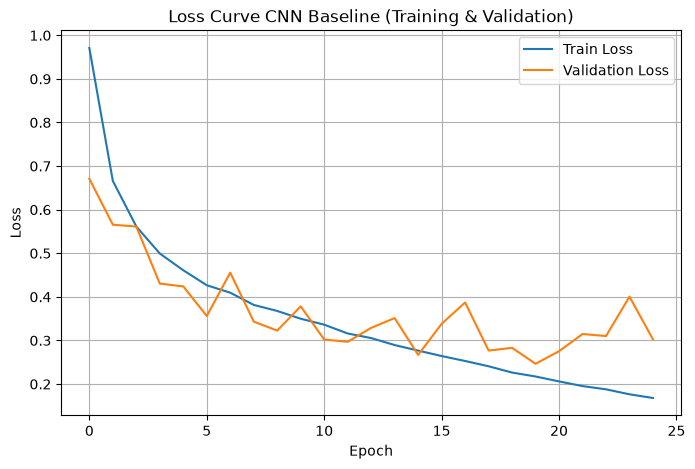

In [16]:
def convert_to_serializable(obj):
    if isinstance(obj, set):
        return list(obj)
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Type {type(obj)} not serializable")

json_path = LOG_TRAIN / "log_train_baseline_CNN.json"
with open(json_path, "w", encoding="utf-8") as json_file:
    json.dump(history, json_file, indent=4, ensure_ascii=False, default=convert_to_serializable)

print(f"Berhasil menyimpan log ke '{json_path}'")
csv_path = LOG_TRAIN / "tabel_log_train_baseline_CNN.csv"
summary_train = pd.DataFrame(history)
summary_train.to_csv(csv_path, index=False)
print(f"Berhasil menyimpan tabel ke '{csv_path}'")

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Curve CNN Baseline (Training & Validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(LOG_TRAIN / "baseline_loss_curve_CNN.png", dpi=300, bbox_inches="tight")
plt.show()


Model terbaik berhasil dimuat
Epoch terbaik: 20
Validation loss terbaik: 0.24648877606169511
Sedang mengevaluasi data test, mohon tunggu...


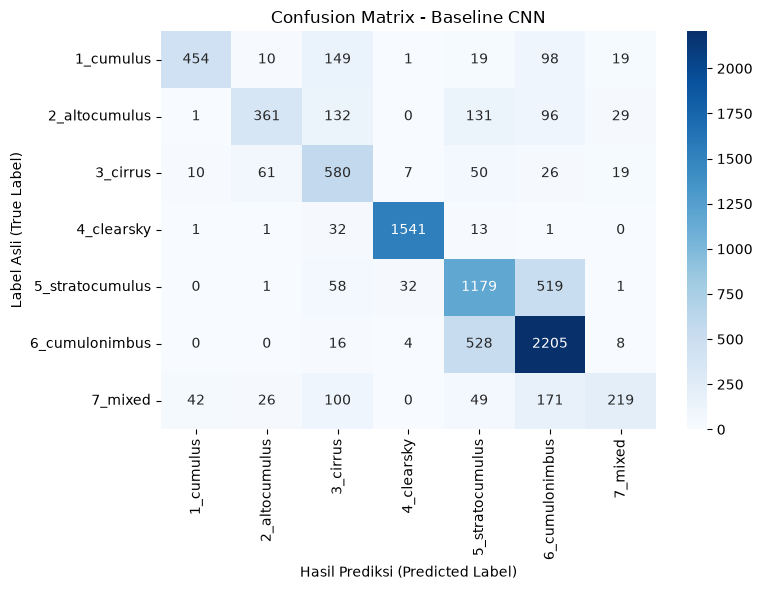


=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

      1_cumulus       0.89      0.61      0.72       750
  2_altocumulus       0.78      0.48      0.60       750
       3_cirrus       0.54      0.77      0.64       753
     4_clearsky       0.97      0.97      0.97      1589
5_stratocumulus       0.60      0.66      0.63      1790
 6_cumulonimbus       0.71      0.80      0.75      2761
        7_mixed       0.74      0.36      0.49       607

       accuracy                           0.73      9000
      macro avg       0.75      0.66      0.68      9000
   weighted avg       0.74      0.73      0.72      9000



In [17]:
best_model_path = TRAIN_MODEL_DIR / 'best_cloud_model_baseline_CNN.pth'
checkpoint = torch.load(best_model_path, map_location=device)

model = CNNBaseline(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model terbaik berhasil dimuat")
print("Epoch terbaik:", checkpoint["epoch"])
print("Validation loss terbaik:", checkpoint["best_val_loss"])

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. HITUNG & TAMPILKAN CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

# Visualisasi menggunakan Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Baseline CNN')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Hasil Prediksi (Predicted Label)')
plt.tight_layout()

# Simpan hasil gambar matrix
plt.savefig(LOG_TEST / 'baseline_confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# 5. CETAK CLASSIFICATION REPORT (METRIK TAMBAHAN)
# ==========================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))


## Batas Baseline

In [25]:
# Cetak daftar kelas dan totalnya
print("Daftar Kelas:", train_dataset.classes)
print("Total Kelas Riil:", len(train_dataset.classes))

# Samakan nilai NUM_CLASSES dengan total kelas riil tersebut
NUM_CLASSES = len(train_dataset.classes) 

Daftar Kelas: ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus', '7_mixed']
Total Kelas Riil: 7


In [ ]:
# ==========================================
# KONFIGURASI PARAMETER (SESUAI SPEK ANDA)
# ==========================================
NUM_CLASSES = NUM_CLASSES = len(train_dataset.classes)
NUM_EPOCHS = 30           # Menggunakan 30 Epoch seperti Baseline Anda
PATIENCE = 5              # Toleransi Early Stopping
LEARNING_RATE = 0.0001    # Sedikit dinaikkan (1e-4) agar classifier baru cepat beradaptasi
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inisialisasi Model ResNet-50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Freeze Backbone
for param in model.parameters():
    param.requires_grad = False

# Ganti Kepala Klasifikasi
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)
model = model.to(DEVICE)

# Loss & Optimizer (Hanya update parameter classifier yang aktif)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

In [26]:
# Tempat menyimpan riwayat metrik untuk grafik nanti
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0

print("Memulai pelatihan ResNet-50 dengan Transfer Learning...")

for epoch in range(NUM_EPOCHS):
    # ------------------------------------------
    # FASE TRAINING (PELATIHAN)
    # ------------------------------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # Reset gradien
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass & Optimasi
        loss.backward()
        optimizer.step()
        
        # Hitung statistik training
        running_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # Hitung rata-rata loss dan akurasi epoch ini
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # ------------------------------------------
    # FASE VALIDASI
    # ------------------------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Matikan perhitungan gradien agar hemat memori
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Hitung statistik validasi
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # Hitung rata-rata loss dan akurasi epoch ini
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Simpan metrik ke dalam history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    # Cetak performa epoch saat ini
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train -> Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}%")
    print(f"  Val   -> Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2f}%")
    
    # ------------------------------------------
    # LOGIKA EARLY STOPPING (PATIENCE = 5)
    # ------------------------------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Simpan model terbaik jika val_loss mengecil
        torch.save(model.state_dict(), TRAIN_MODEL_DIR / 'best_cloud_model_resnet50.pth')
        print(f"  --> [SAVED] Model terbaik baru disimpan!")
    else:
        patience_counter += 1
        print(f"  --> [PATIENCE] Val Loss tidak turun. Progres: {patience_counter}/{PATIENCE}")
        
    # Hentikan paksa jika counter melebihi batas patience Anda
    if patience_counter >= PATIENCE:
        print(f"\n[Early Stopping] Pelatihan dihentikan di Epoch {epoch+1} karena performa validasi stagnan.")
        break

print("\nPelatihan Selesai!")

Memulai pelatihan ResNet-50 dengan Transfer Learning...

Epoch [1/30]
  Train -> Loss: 0.5287 | Acc: 81.23%
  Val   -> Loss: 0.4364 | Acc: 84.35%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [2/30]
  Train -> Loss: 0.4275 | Acc: 84.12%
  Val   -> Loss: 0.3788 | Acc: 86.16%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [3/30]
  Train -> Loss: 0.3890 | Acc: 85.42%
  Val   -> Loss: 0.3512 | Acc: 86.26%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [4/30]
  Train -> Loss: 0.3700 | Acc: 86.03%
  Val   -> Loss: 0.3367 | Acc: 86.46%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [5/30]
  Train -> Loss: 0.3487 | Acc: 86.73%
  Val   -> Loss: 0.3260 | Acc: 87.66%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [6/30]
  Train -> Loss: 0.3412 | Acc: 87.02%
  Val   -> Loss: 0.3322 | Acc: 87.36%
  --> [PATIENCE] Val Loss tidak turun. Progres: 1/5

Epoch [7/30]
  Train -> Loss: 0.3267 | Acc: 87.48%
  Val   -> Loss: 0.3219 | Acc: 87.06%
  --> [SAVED] Model terbaik baru disimpan!

Epo

Berhasil menyimpan log ke 'd:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\logs\train\log_train_transfer_learning_CNN_SVM.json'
Berhasil menyimpan tabel ke 'd:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\logs\train\tabel_log_train_transfer_learning_CNN_SVM.csv'


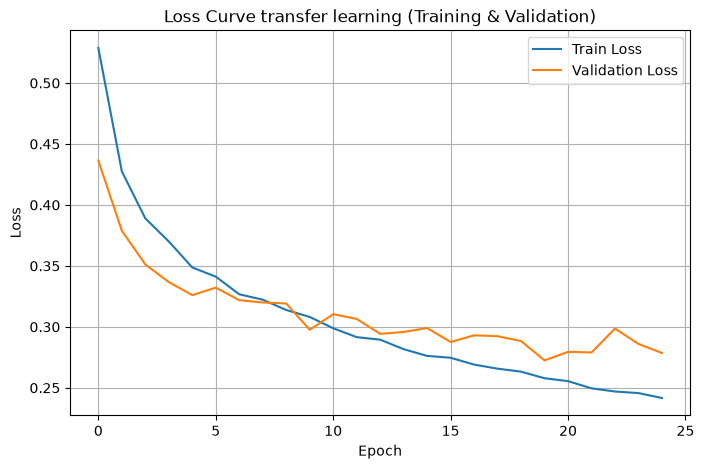

In [28]:
def convert_to_serializable(obj):
    if isinstance(obj, set):
        return list(obj)
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Type {type(obj)} not serializable")

json_path = LOG_TRAIN / "log_train_transfer_learning_CNN_SVM.json"
with open(json_path, "w", encoding="utf-8") as json_file:
    json.dump(history, json_file, indent=4, ensure_ascii=False, default=convert_to_serializable)

print(f"Berhasil menyimpan log ke '{json_path}'")
csv_path = LOG_TRAIN / "tabel_log_train_transfer_learning_CNN_SVM.csv"
summary_train = pd.DataFrame(history)
summary_train.to_csv(csv_path, index=False)
print(f"Berhasil menyimpan tabel ke '{csv_path}'")

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Curve transfer learning (Training & Validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(LOG_TRAIN / "transfer_learning_loss_curve_CNN_SVM.png", dpi=300, bbox_inches="tight")
plt.show()

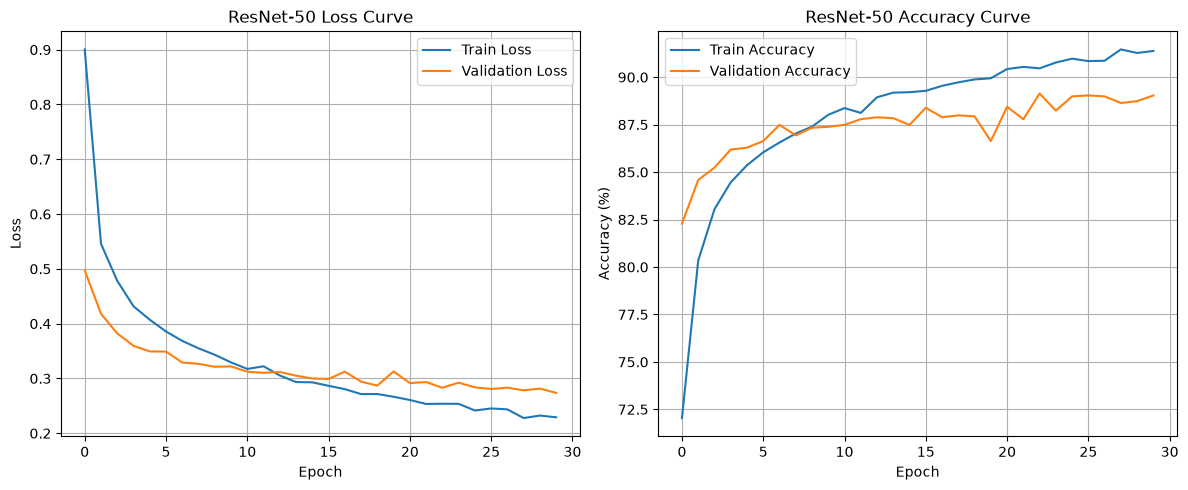

In [ ]:
import matplotlib.pyplot as plt

# Plot Kurva Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('ResNet-50 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Kurva Akurasi
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('ResNet-50 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [29]:
MODEL_PATH =  TRAIN_MODEL_DIR / "best_cloud_model_resnet50.pth"

In [30]:
print(f"Memuat model terbaik dari: {MODEL_PATH}")

Memuat model terbaik dari: d:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\models\train\best_cloud_model_resnet50.pth



Mengumpulkan hasil prediksi dari data validasi...


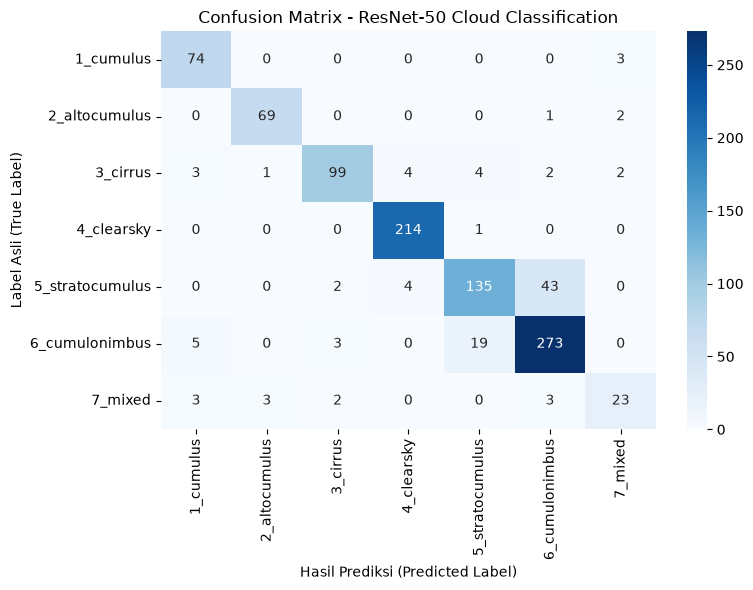


=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

      1_cumulus       0.87      0.96      0.91        77
  2_altocumulus       0.95      0.96      0.95        72
       3_cirrus       0.93      0.86      0.90       115
     4_clearsky       0.96      1.00      0.98       215
5_stratocumulus       0.85      0.73      0.79       184
 6_cumulonimbus       0.85      0.91      0.88       300
        7_mixed       0.77      0.68      0.72        34

       accuracy                           0.89       997
      macro avg       0.88      0.87      0.87       997
   weighted avg       0.89      0.89      0.89       997



In [31]:
# ==========================================
# 2. LOAD MODEL ARSITEKTUR RESNET-50
# ==========================================
model = resnet50()
# Sesuaikan classifier head agar strukturnya sama persis dengan yang Anda latih
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat bobot terbaik (weights) yang berhasil disimpan
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ==========================================
# 3. KUMPULKAN PREDIKSI DAN LABEL ASLI
# ==========================================
all_preds = []
all_labels = []

print("\nMengumpulkan hasil prediksi dari data validasi...")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        # Pindahkan ke CPU dan ubah ke numpy array
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. HITUNG & TAMPILKAN CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

# Visualisasi menggunakan Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ResNet-50 Cloud Classification')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Hasil Prediksi (Predicted Label)')
plt.tight_layout()

# Simpan hasil gambar matrix
plt.savefig(LOG_TEST / 'transfer_learning_confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# 5. CETAK CLASSIFICATION REPORT (METRIK TAMBAHAN)
# ==========================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [36]:
# Transformasi wajib (224x224 & Normalisasi ImageNet)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Memuat Dataset Test
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Sedang mengevaluasi data test, mohon tunggu...

         HASIL EVALUASI AKHIR (DATA TEST)        
                 precision    recall  f1-score   support

      1_cumulus       0.91      0.67      0.77       750
  2_altocumulus       0.87      0.48      0.62       750
       3_cirrus       0.61      0.86      0.72       753
     4_clearsky       0.96      0.98      0.97      1589
5_stratocumulus       0.62      0.58      0.60      1790
 6_cumulonimbus       0.70      0.85      0.76      2761
        7_mixed       0.75      0.39      0.52       607

       accuracy                           0.74      9000
      macro avg       0.78      0.69      0.71      9000
   weighted avg       0.76      0.74      0.74      9000


Grafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'transfer_learning_test_confusion_matrix.png'


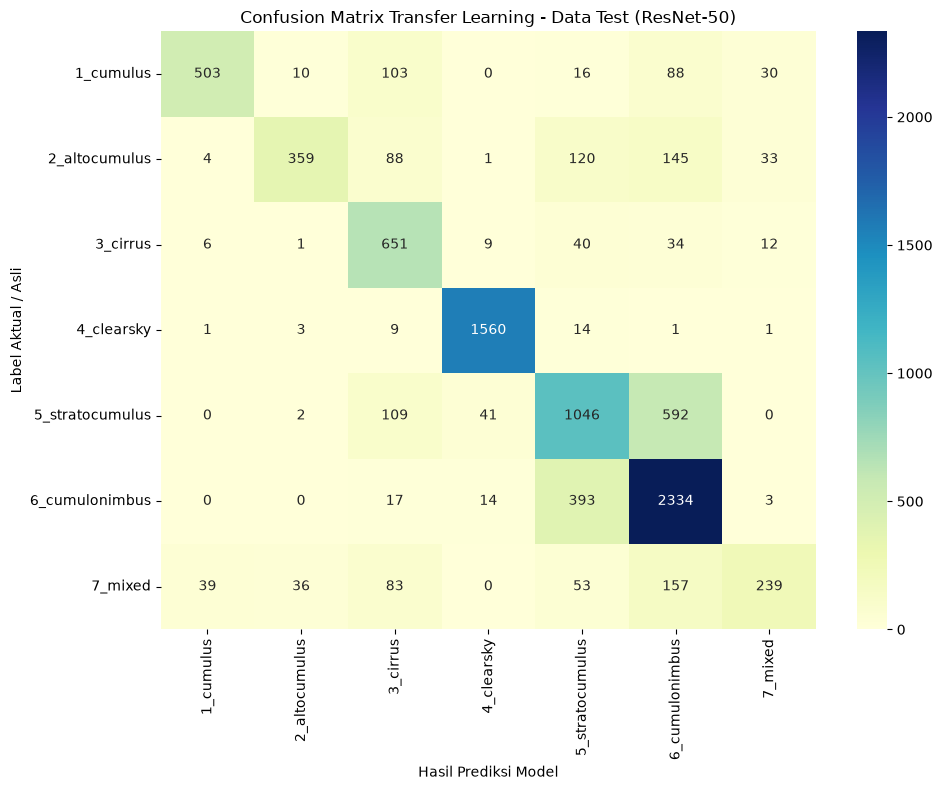

In [37]:
# ==========================================
# 2. MEMUAT ARSITEKTUR & BOBOT MODEL
# ==========================================
model = resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat file .pth hasil training transfer learning kemarin
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval() # Mengaktifkan mode evaluasi (mematikan dropout)

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. TAMPILKAN HASIL AKHIR (CLASSIFICATION REPORT)
# ==========================================
print("\n" + "="*50)
print("         HASIL EVALUASI AKHIR (DATA TEST)        ")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 5. VISUALISASI CONFUSION MATRIX DATA TEST
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Transfer Learning - Data Test (ResNet-50)')
plt.ylabel('Label Aktual / Asli')
plt.xlabel('Hasil Prediksi Model')
plt.tight_layout()

# Simpan matriks data test secara terpisah
plt.savefig(LOG_TEST / 'transfer_learning_test_confusion_matrix.png', dpi=300)
print("\nGrafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'transfer_learning_test_confusion_matrix.png'")
plt.show()

# Fine-Tuning

In [28]:
import torch.nn.functional as F

In [29]:
# ==========================================
# 1. PARAMETER & KONFIGURASI
# ==========================================
NUM_CLASSES = 7
BATCH_SIZE = 32
NUM_EPOCHS = 20           # Fine-tuning tidak butuh epoch terlalu banyak
PATIENCE = 5              # Early stopping lebih sensitif
LEARNING_RATE = 1e-6  # Super kecil (1e-5) agar bobot tidak rusak!

In [33]:
class CloudFocalLoss(nn.Module):
    def __init__(self, gamma=0.8, reduction='mean', eps=1e-7):
        """
        Focal Loss dengan pengaman stabilitas numerik (eps) 
        untuk mencegah nilai 'nan' saat Full Fine-Tuning.
        """
        super(CloudFocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.eps = eps # <-- Nilai pengaman matematika

    def forward(self, inputs, targets):
        # 1. Hitung probabilitas menggunakan softmax biasa
        p = F.softmax(inputs, dim=-1)
        
        # 2. Ambil probabilitas khusus untuk kelas target yang benar
        pt = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        
        # 3. Tambahkan EPSILON pada pt agar tidak pernah bernilai mutlak 0 atau 1
        pt = torch.clamp(pt, self.eps, 1.0 - self.eps)

        # 4. Terapkan rumus matematika Focal Loss dengan Gamma = 0.8 yang aman
        loss = -1 * ((1 - pt) ** self.gamma) * torch.log(pt)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [35]:
# ==========================================
# 3. MUAT MODEL & KONFIGURASI PARSIAL UNFREEZE
# ==========================================
model = models.resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Wajib muat bobot hasil latihan transfer learning Anda sebelumnya
model.load_state_dict(torch.load(TRAIN_MODEL_DIR / 'best_cloud_model_resnet50.pth', map_location=DEVICE))

# --- PROSES UNFREEZE PARSIAL ---
# Pertama, bekukan seluruh parameter model terlebih dahulu
for param in model.parameters():
    param.requires_grad = False

# Kedua, buka kunci khusus untuk LAYER 4 (Blok konvolusi teratas ResNet)
for param in model.layer4.parameters():
    param.requires_grad = True

# Ketiga, pastikan lapisan CLASSIFIER baru Anda tetap aktif terbuka kuncinya
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

# Verifikasi parameter mana saja yang akan dilatih ulang
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameter aktif yang akan di-Fine-Tune: {trainable_params:,}")

# ==========================================
# 4. OPTIMIZER & LOSS FUNCTION
# ==========================================

# criterion = nn.CrossEntropyLoss()
criterion = CloudFocalLoss(gamma=0.2) # Menggunakan Focal Loss stabil yang kita perbaiki sebelumnya

# Filter hanya parameter aktif (layer4 + fc) yang didaftarkan ke optimizer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
# optimizer = optim.SGD(
#     filter(lambda p: p.requires_grad, model.parameters()), 
#     lr=LEARNING_RATE, 
#     momentum=0.9, 
#     weight_decay=1e-4
# )

# ==========================================
# 5. FINE-TUNING TRAINING LOOP
# ==========================================
best_val_loss = float('inf')
patience_counter = 0

print("\n--- Memulai Proses Fine-Tuning Parsial (Layer 4) ---")
for epoch in range(NUM_EPOCHS):
    # --- PHASE TRAINING ---
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # --- PHASE VALIDASI ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # Cek Early Stopping berdasarkan parameter Patience Anda
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Simpan bobot fine-tuned terbaik dengan nama file baru agar tidak menimpa yang lama
        torch.save(model.state_dict(), TEST_MODEL_DIR / 'best_cloud_model_resnet50_finetuned_and_CloudFocalLoss.pth')
        print("  --> [SAVED] Model fine-tuned terbaik disimpan!")
    else:
        patience_counter += 1
        print(f"  --> [PATIENCE] Kemajuan: {patience_counter}/{PATIENCE}")
        
    if patience_counter >= PATIENCE:
        print("\n[Early Stopping] Proses fine-tuning dihentikan karena tidak ada penurunan loss.")
        break

print("\nFine-Tuning Selesai!")

Total parameter aktif yang akan di-Fine-Tune: 15,491,079

--- Memulai Proses Fine-Tuning Parsial (Layer 4) ---
Epoch [1/20] | Train Loss: 0.2163 | Val Loss: 0.2532
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [2/20] | Train Loss: 0.2110 | Val Loss: 0.2504
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [3/20] | Train Loss: 0.2038 | Val Loss: 0.2554
  --> [PATIENCE] Kemajuan: 1/5
Epoch [4/20] | Train Loss: 0.2028 | Val Loss: 0.2527
  --> [PATIENCE] Kemajuan: 2/5
Epoch [5/20] | Train Loss: 0.2008 | Val Loss: 0.2452
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [6/20] | Train Loss: 0.1938 | Val Loss: 0.2444
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [7/20] | Train Loss: 0.1873 | Val Loss: 0.2467
  --> [PATIENCE] Kemajuan: 1/5
Epoch [8/20] | Train Loss: 0.1905 | Val Loss: 0.2514
  --> [PATIENCE] Kemajuan: 2/5
Epoch [9/20] | Train Loss: 0.1860 | Val Loss: 0.2527
  --> [PATIENCE] Kemajuan: 3/5
Epoch [10/20] | Train Loss: 0.1846 | Val Loss: 0.2469
  --> [

In [58]:
MODEL_PATH =  PROJECT_DIR / "testing" / "best_cloud_model_resnet50_finetuned_and_CloudFocalLoss.pth"

Sedang mengevaluasi data test, mohon tunggu...

         HASIL EVALUASI AKHIR (DATA TEST)        
                 precision    recall  f1-score   support

      1_cumulus       0.92      0.68      0.78       750
  2_altocumulus       0.88      0.51      0.64       750
       3_cirrus       0.66      0.86      0.75       753
     4_clearsky       0.96      0.98      0.97      1589
5_stratocumulus       0.62      0.61      0.62      1790
 6_cumulonimbus       0.70      0.83      0.76      2761
        7_mixed       0.78      0.42      0.55       607

       accuracy                           0.75      9000
      macro avg       0.79      0.70      0.72      9000
   weighted avg       0.76      0.75      0.75      9000


Grafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix-Fine-Tuning.png'


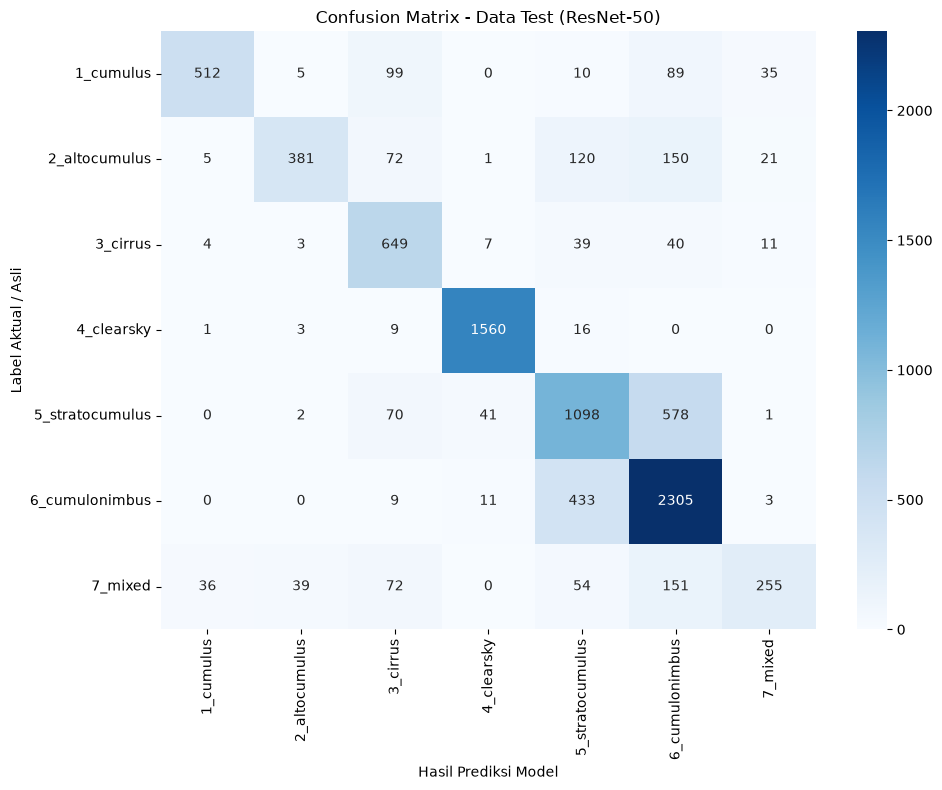

In [59]:
# ==========================================
# 2. MEMUAT ARSITEKTUR & BOBOT MODEL
# ==========================================
model = resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat file .pth hasil training transfer learning kemarin
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval() # Mengaktifkan mode evaluasi (mematikan dropout)

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. TAMPILKAN HASIL AKHIR (CLASSIFICATION REPORT)
# ==========================================
print("\n" + "="*50)
print("         HASIL EVALUASI AKHIR (DATA TEST)        ")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 5. VISUALISASI CONFUSION MATRIX DATA TEST
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Data Test (ResNet-50)')
plt.ylabel('Label Aktual / Asli')
plt.xlabel('Hasil Prediksi Model')
plt.tight_layout()

# Simpan matriks data test secara terpisah
plt.savefig('resnet50_test_confusion_matrix-Fine-Tuning.png', dpi=300)
print("\nGrafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix-Fine-Tuning.png'")
plt.show()